# Vigilancia del dengue en Argentina (2018–2025): limpieza de los casos

Cada semana, el sistema de vigilancia del Ministerio de Salud notifica casos de dengue por provincia, departamento y grupo de edad. Esos boletines se publican como archivos separados, uno por corte, y antes de calcular una sola incidencia hay que asegurarse de que los números que salen de ellos son los que dicen ser. Este notebook parte de esa pregunta: **¿qué hay que corregir en los boletines para que los casos sean comparables entre años y provincias?**

Recorremos los 10 archivos, detectamos qué se repite o se contradice y dejamos un único dataset limpio. Ese dataset alimenta el resto del proyecto: el clima de las estaciones del SMN (notebook 02), el modelo SQL que lee el dashboard de Power BI (03), el análisis de la relación entre clima y brotes (04) y un pronóstico a cuatro semanas (05).

Buscamos respuesta a cinco preguntas:

1. ¿Qué cubre cada archivo, y hay años que se cuentan dos veces?
2. ¿Cómo se escriben las provincias, los departamentos y los grupos de edad, y cuáles son equivalentes?
3. ¿Se puede usar el id de grupo etario que trae la fuente?
4. ¿Qué semanas cubre realmente cada año?
5. ¿Con qué población se calcula la incidencia?

**Fuente:** Ministerio de Salud de la Nación, *Boletín Epidemiológico Nacional: Dengue y Zika*, publicado como datos abiertos en [datos.salud.gob.ar](https://datos.salud.gob.ar/dataset). **Población:** Censo 2022 (INDEC), cargada en `data/raw/poblacion_provincias_censo2022.csv`.

## 1. Carga de los datos

### 1.1 Librerías y rutas

In [1]:
from pathlib import Path
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def encontrar_raiz(archivo=("data", "raw", "Dengue y Zika - Dic. 2019.xlsx")):
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        for candidata in (base, base / "vigilancia-dengue-argentina"):
            if candidata.joinpath(*archivo).exists():
                return candidata
    raise FileNotFoundError("No se encontró data/raw/" + archivo[-1] + " desde " + str(cwd))

ROOT = encontrar_raiz()
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
IMAGES = ROOT / "images"
for carpeta in (INTERIM, PROCESSED, IMAGES):
    carpeta.mkdir(parents=True, exist_ok=True)

# Paleta del dashboard de Power BI (tema "Dengue Portfolio")
AZUL_OSCURO, ROJO, AZUL, NARANJA, VERDE, VIOLETA, AMARILLO, GRIS = (
    "#2C3E50", "#B71C1C", "#1F6FB2", "#E08E45", "#6B8E23", "#8E44AD", "#F1C40F", "#7F8C8D")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#9CA3AF", "axes.labelcolor": "#1F2937", "text.color": "#1F2937",
    "xtick.color": "#374151", "ytick.color": "#374151",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.prop_cycle": plt.cycler(color=[AZUL_OSCURO, ROJO, AZUL, NARANJA, VERDE, VIOLETA, AMARILLO, GRIS]),
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "legend.frameon": False,
})

La raíz del proyecto se busca hacia arriba desde la carpeta de trabajo, así que el notebook corre igual se abra Jupyter donde se abra.

### 1.2 Lectura de los archivos

Hay un `.xlsx` por corte del boletín. Se leen todos y se les agrega una columna con el nombre del archivo de origen, que va a hacer falta para entender las superposiciones.

In [2]:
frames = []
for ruta in sorted(RAW.glob("Dengue y Zika*.xlsx")):
    parcial = pd.read_excel(ruta)
    parcial["archivo"] = ruta.name
    frames.append(parcial)

crudo = pd.concat(frames, ignore_index=True)
crudo = crudo.rename(columns={
    "departamento_id": "id_dpto_origen",
    "departamento_nombre": "departamento",
    "provincia_id": "id_prov_origen",
    "provincia_nombre": "provincia",
    "anio": "año",
    "semanas_epidemiologicas": "SE",
    "evento_nombre": "evento",
    "grupo_edad_id": "id_grupo_edad_origen",
    "grupo_edad_desc": "grupo_edad",
    "cantidad_casos": "cant_casos",
})
print(f"Archivos leídos: {len(frames)}")
print(f"Filas y columnas: {crudo.shape}")

Archivos leídos: 10
Filas y columnas: (107292, 11)


## 2. Primera mirada

### 2.1 Tipos y valores nulos

In [3]:
crudo.info()
display(crudo.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107292 entries, 0 to 107291
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_dpto_origen        107292 non-null  object 
 1   departamento          107291 non-null  object 
 2   id_prov_origen        107291 non-null  float64
 3   provincia             107291 non-null  object 
 4   año                   107291 non-null  float64
 5   SE                    107291 non-null  float64
 6   evento                107291 non-null  object 
 7   id_grupo_edad_origen  107289 non-null  object 
 8   grupo_edad            107291 non-null  object 
 9   cant_casos            107290 non-null  float64
 10  archivo               107292 non-null  object 
dtypes: float64(4), object(7)
memory usage: 9.0+ MB


,id_dpto_origen,departamento,id_prov_origen,provincia,año,SE,evento,id_grupo_edad_origen,grupo_edad,cant_casos,archivo
0,0,*sin dato*,6.0,Buenos Aires,2018.0,11.0,Dengue,10,De 45 a 64 años,1.0,Dengue y Zika - Dic. 2018.xlsx
1,35,Avellaneda,6.0,Buenos Aires,2018.0,7.0,Dengue,8,De 20 a 24 años,1.0,Dengue y Zika - Dic. 2018.xlsx
2,35,Avellaneda,6.0,Buenos Aires,2018.0,7.0,Dengue,10,De 45 a 64 años,1.0,Dengue y Zika - Dic. 2018.xlsx


In [4]:
nulos = crudo.isnull().sum()
display(nulos[nulos > 0].to_frame("nulos"))
display(crudo[crudo["cant_casos"].isnull()])

,nulos
departamento,1
id_prov_origen,1
provincia,1
año,1
SE,1
evento,1
id_grupo_edad_origen,3
grupo_edad,1
cant_casos,2


,id_dpto_origen,departamento,id_prov_origen,provincia,año,SE,evento,id_grupo_edad_origen,grupo_edad,cant_casos,archivo
578,105,LOS ANDES,66.0,Salta,2018.0,11.0,Dengue,6,De 10 a 14 años,NaN,Dengue y Zika - Dic. 2018.xlsx
53896,_x001A_,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dengue y Zika 1 a 52 - 2024 y 2025.xlsx


Entre 107.292 filas, solo dos tienen nulos en la columna de casos: una fila completamente vacía al final del archivo de 2024 (su id de departamento es el carácter de control `_x001A_`) y una fila de Los Andes (Salta) de 2018 sin cantidad de casos. Una fila sin casos no aporta nada, así que se descartan en el paso siguiente.

### 2.2 Qué cubre cada archivo

In [5]:
resumen = (
    crudo.dropna(subset=["año", "cant_casos"])
    .assign(año=lambda d: d["año"].astype(int))
    .groupby(["año", "archivo"])
    .agg(filas=("cant_casos", "size"), casos=("cant_casos", "sum"), SE_max=("SE", "max"))
    .reset_index()
)
resumen["casos"] = resumen["casos"].astype(int)
resumen["SE_max"] = resumen["SE_max"].astype(int)
resumen

,año,archivo,filas,casos,SE_max
0,2018,Dengue y Zika - Dic. 2018.xlsx,659,1201,27
1,2019,Dengue y Zika - Dic. 2019.xlsx,1273,2794,52
2,2020,Dengue y Zika - Dic. 2020.xlsx,11034,58766,53
3,2021,Dengue y Zika - Dic. 2021.xlsx,1164,3991,30
4,2021,Dengue y Zika - Jul. 2021.xlsx,1146,3850,53
5,2022,Dengue y Zika - Dic. 2022.xlsx,293,802,50
6,2023,Dengue y Zika 1 a 52 - Dic. 2023.xlsx,18228,146876,52
7,2024,Dengue y Zika 1 a 52 - 2024 y 2025.xlsx,35256,582267,52
8,2024,Dengue y Zika 1 a 52 - Dic. 2024.xlsx,35167,581433,52
9,2025,Dengue y Zika 1 a 43 - 2025.xlsx,3070,17689,42


La tabla muestra algo importante: **dos años aparecen en más de un archivo**. Antes de seguir hay que entender qué son esas repeticiones.

## 3. Años que aparecen en dos archivos

In [6]:
versiones = resumen.groupby("año")["archivo"].nunique()
años_repetidos = versiones[versiones > 1].index.tolist()
print("Años que aparecen en más de un archivo:", años_repetidos)
resumen[resumen["año"].isin(años_repetidos)]

Años que aparecen en más de un archivo: [2021, 2024]


,año,archivo,filas,casos,SE_max
3,2021,Dengue y Zika - Dic. 2021.xlsx,1164,3991,30
4,2021,Dengue y Zika - Jul. 2021.xlsx,1146,3850,53
7,2024,Dengue y Zika 1 a 52 - 2024 y 2025.xlsx,35256,582267,52
8,2024,Dengue y Zika 1 a 52 - Dic. 2024.xlsx,35167,581433,52


**Hallazgo:** 2021 y 2024 están en dos archivos cada uno. No son partes complementarias de un mismo año sino **dos versiones del mismo año** tomadas en momentos distintos: en 2024 las dos cubren las 52 semanas y comparten casi todas sus filas; en 2021 las dos reportan las mismas semanas con cifras parecidas (hasta la SE 25 en la práctica). Si se concatenan los archivos sin más, esos casos se cuentan dos veces.

La regla que usamos es conservar, para cada año, **la versión con más casos notificados**, porque las versiones más nuevas del boletín suman notificaciones que llegaron tarde. Así queda una sola fila de datos por cada combinación de año, semana, departamento y grupo de edad.

In [7]:
# Regla: de cada año se conserva la versión con más casos notificados
# (las versiones más nuevas del boletín suman notificaciones tardías).
elegido = resumen.sort_values("casos").groupby("año").tail(1).set_index("año")["archivo"]

crudo = crudo.dropna(subset=["año", "cant_casos"]).copy()
crudo["año"] = crudo["año"].astype(int)
casos = crudo[crudo["archivo"] == crudo["año"].map(elegido)].copy()

comparacion = pd.DataFrame({
    "sumando todos los archivos": crudo.groupby("año")["cant_casos"].sum(),
    "una versión por año": casos.groupby("año")["cant_casos"].sum(),
}).astype(int)
comparacion["sobreconteo"] = comparacion.iloc[:, 0] - comparacion.iloc[:, 1]
comparacion

,sumando todos los archivos,una versión por año,sobreconteo
año,,,
2018,1201,1201,0
2019,2794,2794,0
2020,58766,58766,0
2021,7841,3991,3850
2022,802,802,0
2023,146876,146876,0
2024,1163700,582267,581433
2025,17689,17689,0


Sumar todos los archivos habría inflado 2021 en 3.850 casos (96 % más) y 2024 en 581.433 (100 % más). Con la regla, el año más grande de la serie queda en 582.267 casos. Es la corrección más importante de todo el notebook, porque cambia el orden de magnitud del año de mayor actividad.

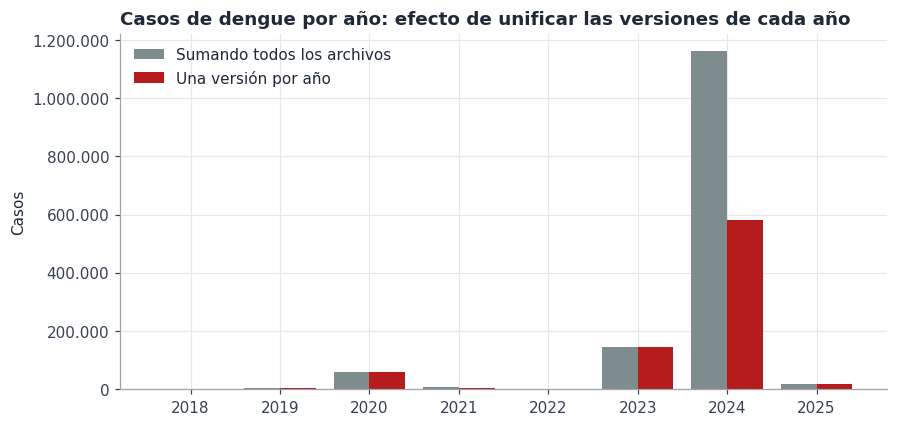

In [8]:
anual = comparacion["una versión por año"]
antes = comparacion["sumando todos los archivos"]

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(anual))
ax.bar(x - 0.2, antes, 0.4, color=GRIS, label="Sumando todos los archivos")
ax.bar(x + 0.2, anual, 0.4, color=ROJO, label="Una versión por año")
ax.set_xticks(x, anual.index.astype(str))
ax.set_ylabel("Casos")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}".replace(",", "."))
ax.set_title("Casos de dengue por año: efecto de unificar las versiones de cada año")
ax.legend()
plt.show()

## 4. Limpieza

### 4.1 Evento

El archivo trae dengue, dengue durante la gestación y Zika. Nos interesa el dengue, así que se descarta el Zika. Además, en el archivo de 2020 el nombre aparece con un espacio al final (`'Dengue '`), que pandas toma como una categoría distinta.

In [9]:
print(casos["evento"].value_counts(dropna=False))
casos["evento"] = (
    casos["evento"].astype(str).str.strip()
    .replace({"Enfermedad por Virus del Zika": "Zika"})
)
zika = casos["evento"] == "Zika"
print(f"\nFilas de Zika que se descartan: {zika.sum()} ({int(casos.loc[zika, 'cant_casos'].sum())} casos)")
casos = casos[~zika].copy()
casos["evento"].value_counts()

evento
Dengue                           69746
Dengue                            1115
Dengue durante la gestación         82
Enfermedad por Virus del Zika       34
Name: count, dtype: int64

Filas de Zika que se descartan: 34 (37 casos)


evento
Dengue                         70861
Dengue durante la gestación       82
Name: count, dtype: int64

Se descartan 34 filas de Zika. Los casos de dengue durante la gestación se conservan como un evento separado.

### 4.2 Provincia y población

In [10]:
casos["provincia"].value_counts(dropna=False).sort_index()

provincia
(en blanco)                5
*sin dato*                 2
Buenos Aires           11742
CABA                    4968
Catamarca               1467
Chaco                   8002
Chubut                    70
Corrientes              2769
Córdoba                 5342
Entre Ríos              2203
Formosa                 3518
Jujuy                   2193
La Pampa                 356
La Rioja                1330
Mendoza                  752
Misiones                4321
Neuquén                  165
Río Negro                 92
SAnta Cruz                 1
SAnta Fe                  30
Salta                   5230
San Juan                 635
San Luis                 567
Santa Cruz               249
Santa Fe                5670
Santiago del Estero     2874
Tierra del Fuego         158
Tucumán                 5583
desconocida              649
Name: count, dtype: int64

Hay tres tipos de problema: erratas de escritura (`SAnta Fe`, `SAnta Cruz`), valores que no son una provincia (`(en blanco)`, `*sin dato*`, `desconocida`) y una jurisdicción que no es provincia (`CABA`).

- Las erratas se corrigen.
- Los valores sin provincia se dejan como nulos: esos casos cuentan en los totales nacionales, pero no se pueden asignar a una provincia.
- CABA se suma a Buenos Aires. Es la convención que usa el dashboard y es coherente con la población que tenemos cargada (la de Buenos Aires incluye a CABA). El clima también: las dos estaciones de CABA se promedian con las de la provincia.

La población sale de un archivo propio, `poblacion_provincias_censo2022.csv`, y no de un diccionario escrito dentro del notebook. Así el denominador de la incidencia queda a la vista y se puede reemplazar sin tocar el código.

In [11]:
ARREGLOS_PROV = {"SAnta Fe": "Santa Fe", "SAnta Cruz": "Santa Cruz", "CABA": "Buenos Aires"}
SIN_DATO_PROV = ["(en blanco)", "*sin dato*", "desconocida"]

casos["provincia"] = casos["provincia"].astype(str).str.strip().replace(ARREGLOS_PROV)
casos.loc[casos["provincia"].isin(SIN_DATO_PROV), "provincia"] = np.nan

poblacion = pd.read_csv(RAW / "poblacion_provincias_censo2022.csv")
desconocidas = set(casos["provincia"].dropna()) - set(poblacion["provincia"])
assert not desconocidas, f"Provincias sin población: {desconocidas}"

casos = casos.merge(poblacion.rename(columns={"habitantes": "cant_habitantes"}), on="provincia", how="left")
sin_prov = casos["provincia"].isna()
print(f"Casos sin provincia identificable: {int(casos.loc[sin_prov, 'cant_casos'].sum())} "
      f"({casos.loc[sin_prov, 'cant_casos'].sum() / casos['cant_casos'].sum():.2%} del total)")
print(f"Provincias: {casos['provincia'].nunique()}")

Casos sin provincia identificable: 28370 (3.48% del total)
Provincias: 23


Quedan 28.370 casos sin provincia identificable (3,5 % del total). Se mantienen en los totales nacionales y quedan fuera de todo cálculo provincial.

### 4.3 Departamento

El mismo departamento aparece escrito de varias maneras (`General Pueyrredon` y `General Pueyrredón`, `Grl. José de San Martín` y `Grl. Jose de San Martin`). La limpieza hace dos cosas:

1. Compara los nombres en minúsculas y sin tildes, y entre las variantes elige la que está mejor escrita.
2. Aplica un pequeño diccionario para las variantes que no se resuelven solo con tildes (`1a de Mayo`, `La Capital`, `Libertador Grl. San Martín`).

Además, un nombre de departamento **no identifica** al departamento: `capital` existe en once provincias. Por eso el identificador `id_dpto` se construye con la pareja provincia + departamento.

In [12]:
def clave(texto):
    """Minúsculas y sin tildes, para detectar el mismo nombre escrito de dos maneras."""
    texto = unicodedata.normalize("NFD", str(texto).strip().lower())
    return "".join(c for c in texto if unicodedata.category(c) != "Mn")

SIN_DATO_DPTO = {"(en blanco)", "*sin dato*", "#¡valor!", "++++++++++++", "2007", "desconocido", "nan"}
# Variantes que no se resuelven solo con tildes (clave observada -> nombre definitivo)
ALIAS_DPTO = {
    "libertador grl. san martin": "libertador general san martín",
    "grl. jose de san martin": "general josé de san martín",
    "1a de mayo": "1º de mayo",
    "1° de mayo": "1º de mayo",
    "la capital": "capital",
}

texto = casos["departamento"].astype(str).str.strip().str.lower()
clave_dpto = texto.map(clave)
sin_dato = clave_dpto.isin(SIN_DATO_DPTO)

tabla = pd.DataFrame({"provincia": casos["provincia"].fillna("sin dato"), "clave": clave_dpto, "texto": texto})[~sin_dato]
tabla["tildes"] = tabla["texto"].map(lambda t: sum(ord(c) > 127 for c in t))
# Entre las variantes de un mismo nombre se elige la que tiene más tildes (la mejor escrita)
mejor = tabla.sort_values("tildes").groupby(["provincia", "clave"])["texto"].last()

def nombre_final(prov, cl):
    return ALIAS_DPTO.get(cl) or mejor[(prov, cl)]

casos["departamento"] = [
    np.nan if sd else nombre_final(p, c)
    for sd, p, c in zip(sin_dato, casos["provincia"].fillna("sin dato"), clave_dpto)
]
print(f"Departamentos distintos: {casos.groupby(['provincia', 'departamento']).ngroups}")
print(f"Filas sin departamento: {casos['departamento'].isna().sum()}")

Departamentos distintos: 517
Filas sin departamento: 1291


In [13]:
# El nombre solo no alcanza como clave ("capital" existe en 11 provincias), así que el id sale de provincia + departamento
dptos = (casos[["provincia", "departamento"]].dropna().drop_duplicates()
         .sort_values(["provincia", "departamento"]).reset_index(drop=True))
dptos["id_dpto"] = np.arange(1, len(dptos) + 1)
casos = casos.merge(dptos, on=["provincia", "departamento"], how="left")
casos["id_dpto"] = casos["id_dpto"].fillna(0).astype(int)
casos[["id_dpto", "provincia", "departamento"]].drop_duplicates().head()

,id_dpto,provincia,departamento
0,0,Buenos Aires,NaN
1,8,Buenos Aires,avellaneda
36,15,Buenos Aires,berazategui
38,56,Buenos Aires,ezeiza
40,57,Buenos Aires,florencio varela


Quedan 517 departamentos distintos. Las filas sin departamento identificable concentran 30.330 casos (3,7 % del total); se mantienen con departamento nulo.

### 4.4 Grupo de edad

In [14]:
casos["grupo_edad"].value_counts(dropna=False)

grupo_edad
De 45 a 65 años                   8488
De 25 a 34 años                   8352
De 35 a 44 años                   7602
De 20 a 24 años                   6385
De 15 a 19 años                   5872
De 10 a 14 años                   5500
Mayores de 65 años                5490
De 5 a 9 años                     4538
De 2 a 4 años                     2540
De 25 a 34 anos                   2144
De 35 a 44 anos                   1997
De 45 a 65 anos                   1970
De 20 a 24 anos                   1618
De 15 a 19 anos                   1475
De 13 a 24 meses                  1325
De 10 a 14 anos                   1233
Mayores de 65 anos                1026
De 5 a 9 anos                      966
Posneonato (29 hasta 365 dÍas)     816
De 2 a 4 anos                      505
Posneonato (29 hasta 365 días)     293
Neonato (hasta 28 dÍas)            145
De 45 a 64 anos                    135
Posneonato (de 29 a 365 días)      116
De 45 a 64 años                    114
Sin Especifica

Los 34 rótulos originales corresponden a solo 13 grupos de edad. Las diferencias son de forma: con o sin tilde (`años` y `anos`), mayúsculas (`dÍas`), redacción (`Mayores de 65` y `Mayor o igual de 65`) y un límite que cambia entre archivos (`45 a 64` y `45 a 65`).

**Hallazgo:** los ids de grupo que trae la fuente no se pueden usar. Cambian de significado de un archivo a otro: 12 de los 14 ids distintos agrupan más de un grupo de edad (el id 4, por ejemplo, es "De 2 a 4 años" en unos archivos y "De 5 a 9 años" en otros). Por eso se descartan y se construye un id nuevo, de 1 a 13, a partir del rótulo ya normalizado.

Una decisión de criterio: `Menor que 1 año` (5 filas) no se puede repartir entre neonato y posneonato, así que va a `Edad sin esp`.

In [15]:
GRUPOS = ["Neonato (hasta 28 dias)", "Posneonato (de 29 a 365 dias)", "De 13 a 24 meses",
          "De 2 a 4 años", "De 5 a 9 años", "De 10 a 14 años", "De 15 a 19 años",
          "De 20 a 24 años", "De 25 a 34 años", "De 35 a 44 años", "De 45 a 64 años",
          "De 65 años o más", "Edad sin esp"]
POR_CLAVE = {clave(g): g for g in GRUPOS[3:10]}      # "de 2 a 4 anos" -> "De 2 a 4 años", etc.

def grupo_edad(texto):
    if pd.isna(texto):
        return GRUPOS[12]
    t = clave(texto)                              # minúsculas y sin tildes: "años" y "anos" quedan iguales
    if t.startswith("neonato"):
        return GRUPOS[0]
    if t.startswith("posneonato"):
        return GRUPOS[1]
    if t in ("de 13 a 24 meses", "igual a 1 ano"):
        return GRUPOS[2]
    if t.startswith("de 45 a 6"):                 # el rótulo cambia entre "45 a 64" y "45 a 65"
        return GRUPOS[10]
    if t.startswith("mayor"):
        return GRUPOS[11]
    return POR_CLAVE.get(t, GRUPOS[12])           # "Sin especificar", "Edad sin esp." y "Menor que 1 año"

# Los ids originales cambian de significado entre archivos: un mismo id agrupa edades distintas
prueba = (crudo.assign(id_origen=pd.to_numeric(crudo["id_grupo_edad_origen"], errors="coerce"),
                       grupo_limpio=crudo["grupo_edad"].map(grupo_edad))
          .dropna(subset=["id_origen"])
          .groupby("id_origen")["grupo_limpio"].nunique())
print("Ids originales que agrupan más de un grupo de edad:")
print(prueba[prueba > 1].rename("grupos distintos").astype(int).to_string())

casos["grupo_edad"] = casos["grupo_edad"].map(grupo_edad)
casos["id_grupo_edad"] = casos["grupo_edad"].map({g: i + 1 for i, g in enumerate(GRUPOS)})
casos["grupo_edad"] = pd.Categorical(casos["grupo_edad"], categories=GRUPOS, ordered=True)
casos.groupby("grupo_edad", observed=False)["cant_casos"].sum().astype(int).to_frame("casos")

Ids originales que agrupan más de un grupo de edad:
id_origen
1.0     3
2.0     2
3.0     2
4.0     2
5.0     2
6.0     2
7.0     2
8.0     2
9.0     2
10.0    2
11.0    2
12.0    2


,casos
grupo_edad,
Neonato (hasta 28 dias),296
Posneonato (de 29 a 365 dias),3545
De 13 a 24 meses,4000
De 2 a 4 años,14737
De 5 a 9 años,47175
De 10 a 14 años,70598
De 15 a 19 años,74726
De 20 a 24 años,79101
De 25 a 34 años,158390


### 4.5 Semana epidemiológica y fechas

Cada fila trae el año y la semana epidemiológica (SE). Para poder cruzar los casos con el clima, que es diario, convertimos cada SE en una fecha de inicio y de fin con el calendario ISO (lunes a domingo). Es una aproximación a la semana epidemiológica oficial, que puede desfasarse unos días, y no altera ningún cálculo a escala semanal o mensual.

In [16]:
casos["SE"] = casos["SE"].astype(int)
semana_iso = casos["año"].astype(str) + "-W" + casos["SE"].astype(str).str.zfill(2)
casos["SE_inicio"] = pd.to_datetime(semana_iso + "-1", format="%G-W%V-%u", errors="coerce")
casos["SE_fin"] = pd.to_datetime(semana_iso + "-7", format="%G-W%V-%u", errors="coerce")

print("SE entre", casos["SE"].min(), "y", casos["SE"].max())
print("Filas con fecha de semana no válida:", int(casos["SE_inicio"].isna().sum()))
casos.loc[casos["SE_inicio"].isna(), ["año", "SE", "cant_casos", "archivo"]]

SE entre 1 y 53
Filas con fecha de semana no válida: 0


,año,SE,cant_casos,archivo


### 4.6 Controles de calidad

In [17]:
print("Casos <= 0:", int((casos["cant_casos"] <= 0).sum()))
print("Casos no enteros:", int((casos["cant_casos"] % 1 != 0).sum()))
print("Años:", sorted(casos["año"].unique()))
print("Provincias sin población asignada (excluye 'sin dato'):",
      int(casos.loc[casos["provincia"].notna(), "cant_habitantes"].isna().sum()))

Casos <= 0: 0
Casos no enteros: 0
Años: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Provincias sin población asignada (excluye 'sin dato'): 0


No hay casos negativos ni decimales, y cada año y cada provincia tienen el dato que esperamos.

## 5. Dataset final

Después de normalizar rótulos, varias filas quedan con la misma clave (mismo departamento, semana, evento y grupo de edad). La fuente reparte los casos de una misma clave en más de una fila, en su mayoría con cantidades distintas entre sí (no son copias), probablemente por una variable que no figura en la exportación. Como cada fila es un **conteo**, no un registro individual, se suman: pasamos de 70.943 a 70.194 filas sin perder ni un caso, y el código lo verifica.

In [18]:
CLAVE = ["id_dpto", "departamento", "id_prov", "provincia", "cant_habitantes", "año", "SE",
         "SE_inicio", "SE_fin", "evento", "id_grupo_edad", "grupo_edad"]

antes = len(casos)
limpio = (casos.groupby(CLAVE, dropna=False, observed=True)["cant_casos"].sum()
          .reset_index().astype({"cant_casos": int}))
print(f"Filas antes de agrupar: {antes:,} | después: {len(limpio):,}")
assert limpio["cant_casos"].sum() == casos["cant_casos"].sum(), "Se perdieron casos al agrupar"
limpio = limpio.sort_values(["año", "SE", "provincia", "departamento", "id_grupo_edad"]).reset_index(drop=True)
limpio.head()

Filas antes de agrupar: 70,943 | después: 70,194


,id_dpto,departamento,id_prov,provincia,cant_habitantes,año,SE,SE_inicio,SE_fin,evento,id_grupo_edad,grupo_edad,cant_casos
0,270,formosa,34.0,Formosa,606041.0,2018,1,2018-01-01,2018-01-07,Dengue,8,De 20 a 24 años,3
1,355,capital,54.0,Misiones,1280960.0,2018,2,2018-01-08,2018-01-14,Dengue,9,De 25 a 34 años,1
2,270,formosa,34.0,Formosa,606041.0,2018,3,2018-01-15,2018-01-21,Dengue,11,De 45 a 64 años,1
3,165,2 de abril,22.0,Chaco,1142963.0,2018,4,2018-01-22,2018-01-28,Dengue,9,De 25 a 34 años,1
4,477,capital,86.0,Santiago del Estero,1054028.0,2018,5,2018-01-29,2018-02-04,Dengue,9,De 25 a 34 años,1


### 5.1 Qué semanas cubre cada año

In [19]:
cobertura = (limpio.groupby("año")
             .agg(casos=("cant_casos", "sum"), SE_min=("SE", "min"), SE_max=("SE", "max")))
cobertura["cobertura"] = np.where(cobertura["SE_max"] >= 52, "año completo", "año parcial")
cobertura

,casos,SE_min,SE_max,cobertura
año,,,,
2018,1164,1,27,año parcial
2019,2794,1,52,año completo
2020,58766,1,53,año completo
2021,3991,1,30,año parcial
2022,802,4,50,año parcial
2023,146876,1,52,año completo
2024,582267,1,52,año completo
2025,17689,1,42,año parcial


**Hallazgo:** no todos los años llegan hasta la SE 52. Terminan antes: 2018 (hasta la SE 27), 2021 (hasta la SE 30), 2022 (hasta la SE 50), 2025 (hasta la SE 42). Las semanas posteriores no figuran en el boletín, y no sabemos si hubo casos o no, así que se las trata como **semanas sin dato** y no como semanas con cero casos; a lo largo del proyecto se las excluye. Los totales anuales de esos años no se pueden comparar con los de los años completos.

### 5.2 Guardado

In [20]:
salida = INTERIM / "dengue_casos_limpio.csv"
limpio.to_csv(salida, index=False, encoding="utf-8")
print(f"Guardado: {salida.relative_to(ROOT)} | {limpio.shape[0]:,} filas, {limpio.shape[1]} columnas")

Guardado: data\interim\dengue_casos_limpio.csv | 70,194 filas, 13 columnas


## 6. Resumen

El dataset limpio tiene 70.194 filas y 814.349 casos de dengue entre 2018 y 2025. Quedó resuelto:

- Las dos versiones de 2021 y 2024 se unificaron, con lo que se eliminan 585.283 casos contados dos veces.
- Provincias, departamentos y grupos de edad quedaron con un único nombre y un id estable.
- Cada año tiene registrada su cobertura real, y los años parciales están identificados.

En el notebook siguiente armamos la otra mitad del problema: el clima de cada provincia, semana a semana.